In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
from sklearn.model_selection import train_test_split
# Neuroimaging
import ants

In [2]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import ct
import mri

In [9]:
model_name = 'alpha=1.0_criterion=L1_lr=0.1_pooling=ABMIL_seed=1001'
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True'
model_history_df1 = pd.read_csv(f'{experiments_dir}/{model_name}.csv', index_col=0)
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/reproducibility_test'
model_history_df2 = pd.read_csv(f'{experiments_dir}/{model_name}.csv', index_col=0)
model_history_df1.head()

,epoch,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,0.0,0.543890,0.281124,0.5,228.553719,0.572671,0.532568,0.292817,0.534219,777.235988,0.646143,0.507171,0.233163,0.5,228.499096,0.518049
1,1.0,0.487947,0.277250,0.5,102.078442,0.627620,0.478197,0.225282,0.500000,195.419100,0.617218,0.549965,0.294600,0.5,102.060354,0.609532
2,2.0,0.475440,0.266238,0.5,48.181475,0.658250,0.484455,0.223397,0.500000,77.831692,0.640602,0.508666,0.295559,0.5,48.173151,0.649927
3,3.0,0.465964,0.260978,0.5,33.465473,0.669438,0.499720,0.234930,0.500000,39.301567,0.661932,0.466140,0.260705,0.5,33.460107,0.664071
4,4.0,0.633338,0.330974,0.5,28.757334,0.677225,0.496396,0.242600,0.500000,31.210895,0.671637,0.615231,0.317579,0.5,28.754064,0.673955


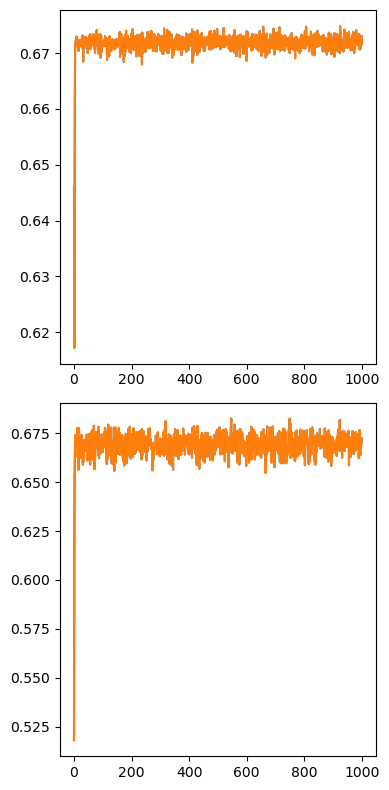

In [11]:
ncols, nrows = 1, 2
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols,4*nrows))

axs[0].plot(model_history_df1.epoch, model_history_df1.train_nll)
axs[0].plot(model_history_df2.epoch, model_history_df2.train_nll)

axs[1].plot(model_history_df1.epoch, model_history_df1.val_nll)
axs[1].plot(model_history_df2.epoch, model_history_df2.val_nll)

fig.tight_layout()

plt.show()